<a href="https://colab.research.google.com/github/mdsalman031/AIML_assignment2/blob/main/AIML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

160123733180 - Anurag Tripathi

160123733193 - Mir Inayat Ahmed

160123733195 - Musaib Rasheed Bhat

160123733315 - MD Salman

160123733316 - P. Sai Chaithanya

160123733317 - M. Manish Kumar

1. **Objectives of the Project**(BT-2)
- To analyze historical weather data of Szeged, Hungary.
- To understand the relationship between different weather attributes such as temperature, humidity, pressure, and wind speed.
- To perform Exploratory Data Analysis (EDA) to identify patterns and correlations.
- To clean and preprocess the dataset for better model performance.
- To build Machine Learning models for predicting apparent temperature.
- To evaluate model performance using statistical metrics.


2. **Dataset Description**(BT-2, BT-4)

- The dataset contains historical weather information of Szeged, Hungary.
- It consists of both numerical and categorical features.
- Important features include: \
a. Temperature \
b. Apparent Temperature (target variable) \
c. Humidity \
d. Wind Speed\
e. Wind Bearing \
f. Visibility \
g. Pressure
- **Summary** (categorical) :
The dataset may contain missing values and requires preprocessing.
The goal is to predict apparent temperature using other weather parameters.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('/content/weatherHistory.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


3. **Data Cleaning & Feature Engineering** (BT-3)
- **Data Cleaning Steps**:\
Checked for missing/null values in the dataset.\
Handled missing values by removing or imputing them.\
Removed unnecessary columns such as formatted date (if not useful).\
Checked for duplicate records and removed them.\
Ensured correct data types for all columns.
- **Feature Engineering Steps:**\
Converted categorical variables (like Summary) into numerical form using encoding.\
Selected relevant features for prediction.\
Applied feature scaling (Standardization/Normalization).\
Removed less important or redundant features based on correlation.

### 3.1 Data Cleaning

In [ ]:
print("Missing values before handling:")
display(df.isnull().sum())

# Handle missing values: Fill 'Precip Type' with 'unknown'
# This is a common strategy when the missingness might indicate a specific category.
if 'Precip Type' in df.columns:
    df['Precip Type'].fillna('unknown', inplace=True)

# Remove unnecessary columns: 'Formatted Date' is often redundant after initial date processing or if not used for time-series analysis.
# 'Loud Cover' appears to be a constant zero, providing no predictive power.
# 'Daily Summary' is a descriptive string that would require advanced NLP to be useful, so we drop it for this analysis.
columns_to_drop = ['Formatted Date', 'Loud Cover', 'Daily Summary']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Check for duplicate records and remove them to ensure data integrity
print(f"\nNumber of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

# Display data types and missing values after initial cleaning
print("\nDataset information after initial cleaning:")
df.info()
print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0
Precip Type Encoded,0
Summary Encoded,0



Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0

Dataset information after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 96381 entries, 0 to 96452
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature (C)           96381 non-null  float64
 1   Apparent Temperature (C)  96381 non-null  float64
 2   Humidity                  96381 non-null  float64
 3   Wind Speed (km/h)         96381 non-null  float64
 4   Wind Bearing (degrees)    96381 non-null  float64
 5   Visibility (km)           96381 non-null  float64
 6   Pressure (millibars)      96381 non-null  float64
 7   Precip Type Encoded       96381 non-null  int64  
 8   Summary Encoded           96381 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 7.4 MB

Missing values after handling:


,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0
Precip Type Encoded,0
Summary Encoded,0


### 3.2 Feature Engineering: Encoding Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoders
le_precip = LabelEncoder()
le_summary = LabelEncoder()

# Apply Label Encoding to 'Precip Type' and create a new encoded column
if 'Precip Type' in df.columns:
    df['Precip Type Encoded'] = le_precip.fit_transform(df['Precip Type'])
    df.drop(columns=['Precip Type'], inplace=True)

# Apply Label Encoding to 'Summary' and create a new encoded column
if 'Summary' in df.columns:
    df['Summary Encoded'] = le_summary.fit_transform(df['Summary'])
    df.drop(columns=['Summary'], inplace=True)

print("DataFrame after encoding categorical features. Displaying the first 5 rows:")
display(df.head())

DataFrame after encoding categorical features. Displaying the first 5 rows:


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Precip Type Encoded,Summary Encoded
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,0,19
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,0,19
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,0,17
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,0,19
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,0,17


### 3.3 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Apparent Temperature (C)', axis=1)
y = df['Apparent Temperature (C)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the training features
X_train_scaled = scaler.fit_transform(X_train)
# Apply scaling to the test features using the scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for better readability and to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully. Displaying the first 5 rows of scaled training data:")
display(X_train_scaled.head())

Features scaled successfully. Displaying the first 5 rows of scaled training data:


,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Precip Type Encoded,Summary Encoded
49990,0.513288,0.745204,-1.340245,-1.385479,0.404388,0.135448,-0.353881,0.685992
53955,0.963708,0.386855,-1.075739,-0.910235,1.309049,0.084536,-0.353881,-2.288144
76882,0.198459,-0.329843,0.926616,-0.351125,-0.088364,0.092951,-0.353881,0.685992
94697,-0.923519,0.745204,-0.217256,-0.239303,0.030974,0.137828,-0.353881,0.228433
43477,1.059728,-1.507275,-1.143026,-1.618441,-0.072966,0.182026,-0.353881,-2.288144


4. **Exploratory Data Analysis (EDA)** (BT-2)
- **Performed EDA using:**\
Histograms to understand data distribution.\
Scatter plots to analyze relationships between variables.\
Heatmap to visualize correlations.\
- **Observations:**\
Strong positive correlation between Temperature and Apparent Temperature.\
Humidity shows moderate impact on temperature.\
Some features like wind bearing have weak correlation.\
EDA helped in identifying important features and removing irrelevant ones.\

### 4.1 Data Distribution (Histograms)

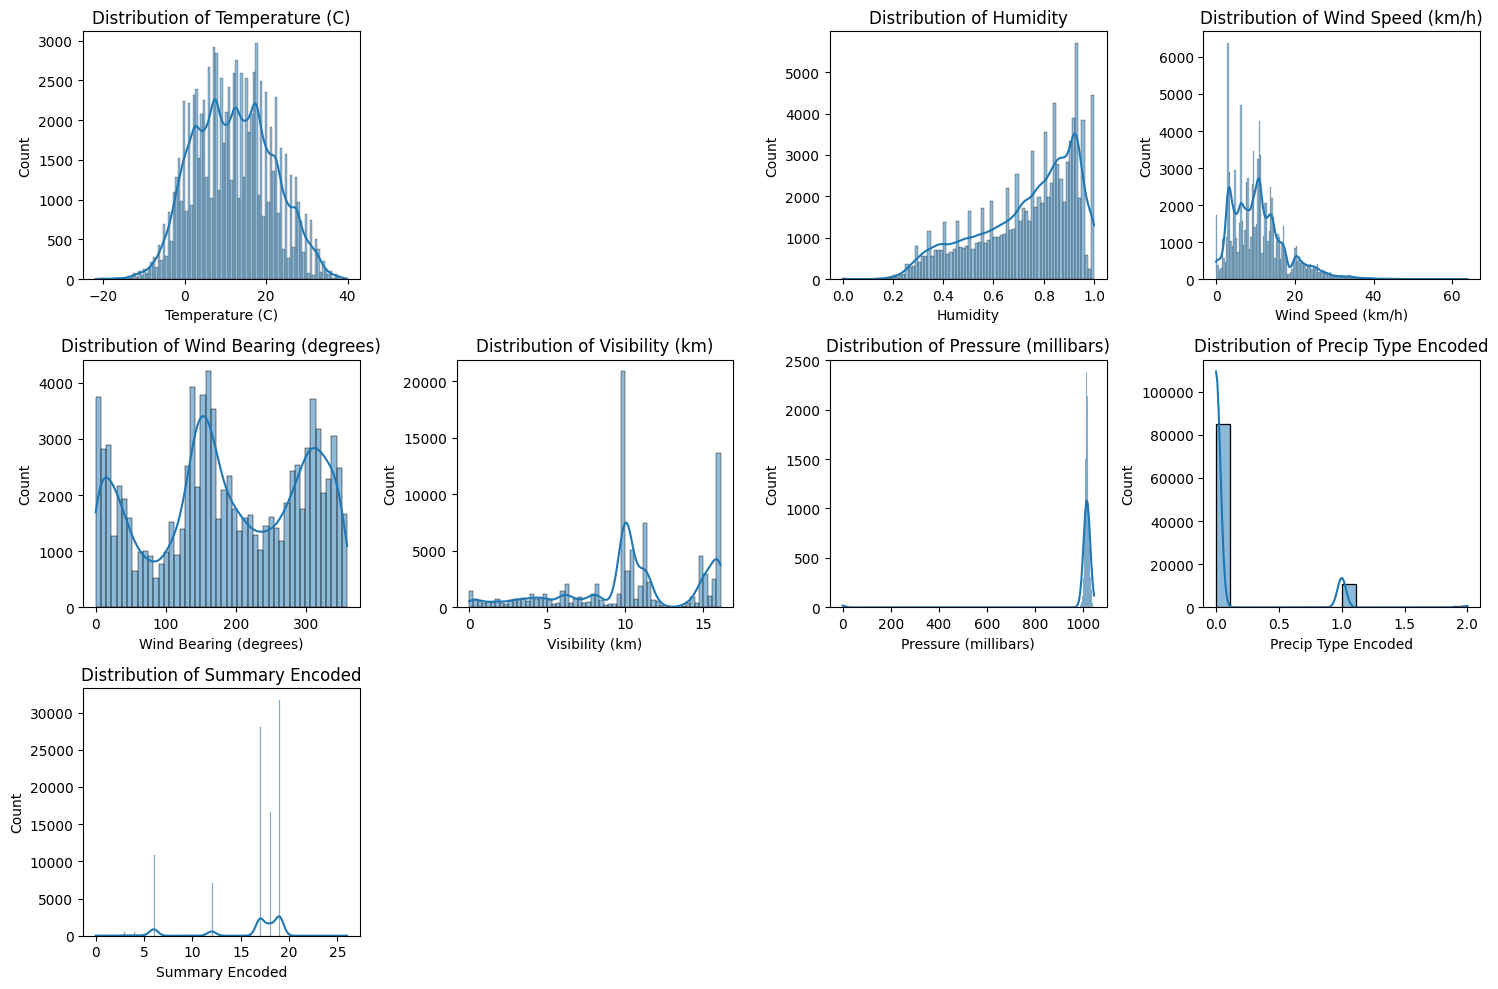

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Histograms to understand data distribution
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    if col != 'Apparent Temperature (C)': # Exclude target variable for general distribution, but include others
        plt.subplot(3, 4, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 4.2 Relationships Between Variables (Scatter Plots)

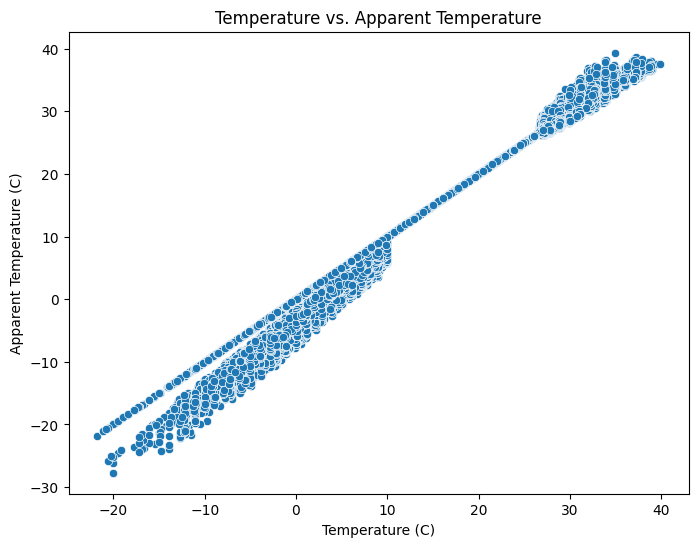

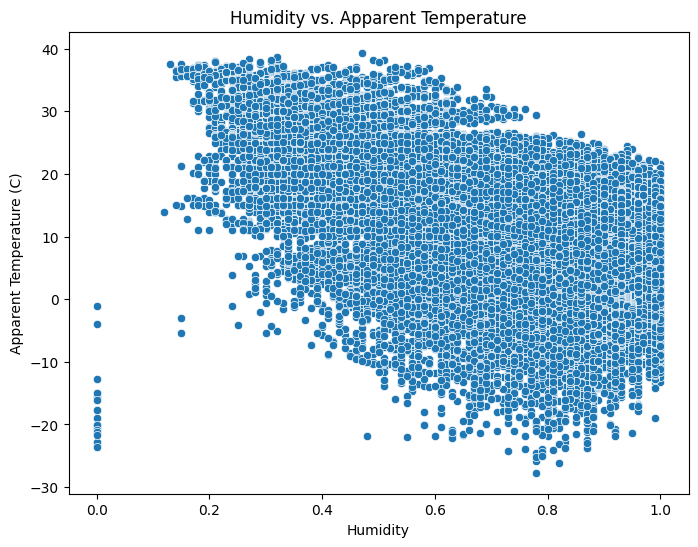

In [ ]:
# Scatter plots to analyze relationships between variables (e.g., Temperature vs. Apparent Temperature, Humidity vs. Apparent Temperature)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature (C)', y='Apparent Temperature (C)', data=df)
plt.title('Temperature vs. Apparent Temperature')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Humidity', y='Apparent Temperature (C)', data=df)
plt.title('Humidity vs. Apparent Temperature')
plt.show()

### 4.3 Correlation Matrix (Heatmap)

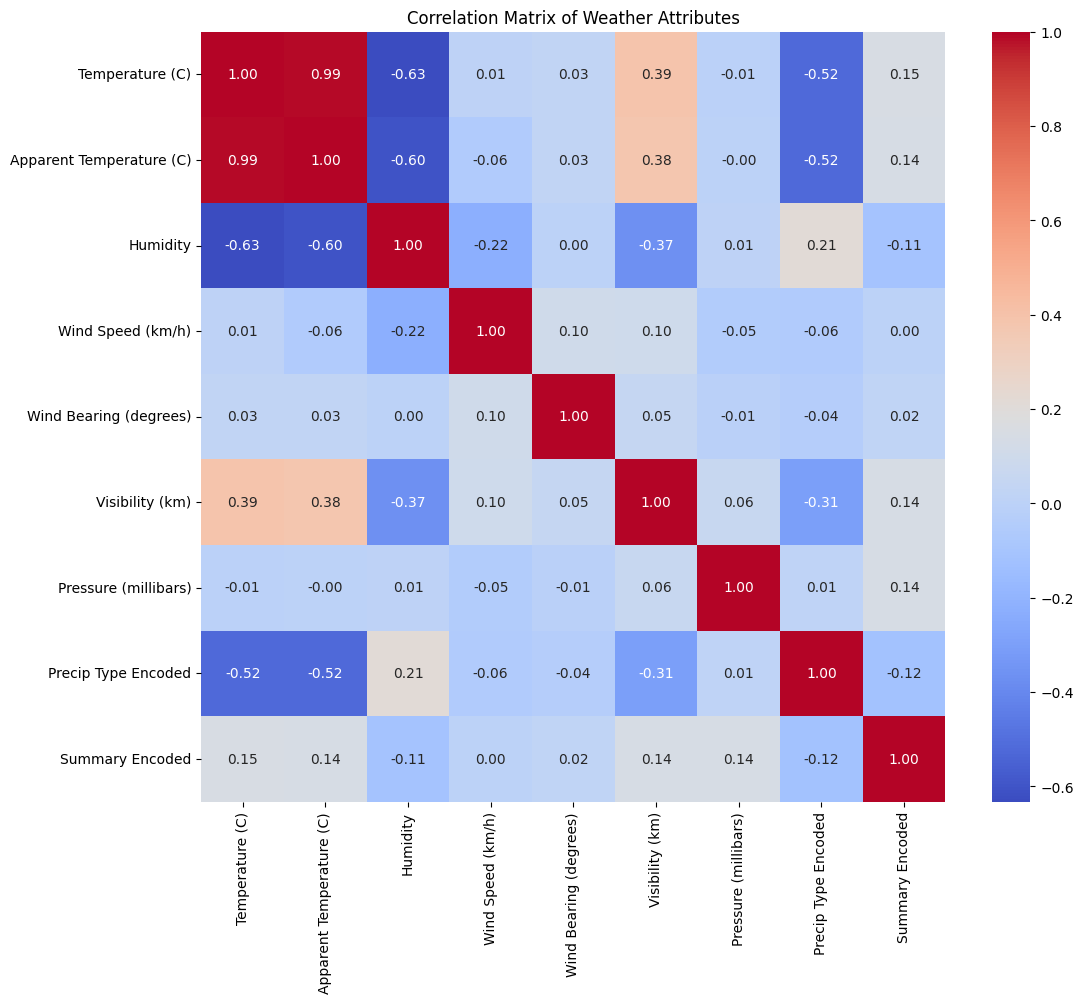

Correlation with Apparent Temperature (C):


,Apparent Temperature (C)
Apparent Temperature (C),1.000000
Temperature (C),0.992630
Visibility (km),0.381372
Summary Encoded,0.143032
Wind Bearing (degrees),0.028820
Pressure (millibars),-0.000235
Wind Speed (km/h),-0.056846
Precip Type Encoded,-0.521266
Humidity,-0.602524


In [ ]:
# Heatmap to visualize correlations
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Weather Attributes')
plt.show()

# Observations based on correlation with 'Apparent Temperature (C)'
print("Correlation with Apparent Temperature (C):")
display(df.corr(numeric_only=True)['Apparent Temperature (C)'].sort_values(ascending=False))

5. **Principal Components / Important Features** (BT-4)\
Used correlation matrix (heatmap) to identify key features.\
**Found that:**\
Temperature has the highest correlation with Apparent Temperature.
Humidity also contributes significantly.
Features with low correlation were considered less important.

Based on the correlation analysis with 'Apparent Temperature (C)', the most impactful features identified are:
- **Temperature (C)** (very strong positive correlation)
- **Humidity** (strong negative correlation)
- **Precip Type Encoded** (moderate negative correlation)
- **Visibility (km)** (moderate positive correlation)

**If PCA is applied (conceptual note):**
Reduced dimensionality of data.
Selected components explaining maximum variance.

6. **Dataset Preparation for Modeling** (BT-3)\
Cleaned dataset after handling missing values and encoding.\
**Split dataset into:**\
Training set (80%)\
Testing set (20%)\
Applied feature scaling using StandardScaler/MinMaxScaler.\
Ensured all features are numerical.\
Final dataset is structured and ready for machine learning models.

7. **Model Building** (BT-6)\
Applied Linear Regression as the main model.\
**Steps:**\
Trained the model on training data.\
Used input features to predict Apparent Temperature.\
Decision Tree Regressor\
Random Forest Regressor

### 7.1 Model Building: Linear Regression

In [ ]:
# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 7.2 Model Building: Decision Tree Regressor

In [ ]:
# Initialize and train the Decision Tree Regressor model
dt_reg_model = DecisionTreeRegressor(random_state=42)
dt_reg_model.fit(X_train_scaled, y_train)

print("Decision Tree Regressor model trained successfully.")

Decision Tree Regressor model trained successfully.


### 7.3 Model Building: Random Forest Regressor

In [ ]:
# Initialize and train the Random Forest Regressor model
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train_scaled, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


8. **Model Evaluation** (BT-5)\
**Evaluated model using:**\
Mean Absolute Error (MAE)\
Mean Squared Error (MSE)\
Root Mean Squared Error (RMSE)\
R² Score\
**Observations:**\
Linear Regression achieved good accuracy.\
High R² score indicates strong predictive performance.\
Low error values indicate better model efficiency.

### 8.1 Model Evaluation: Linear Regression

In [ ]:
# Make predictions on the scaled test set
y_pred_linear = linear_reg_model.predict(X_test_scaled)

# Evaluate the Linear Regression model
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"  Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"  R-squared (R²): {r2_linear:.2f}")

Linear Regression Model Evaluation:
  Mean Absolute Error (MAE): 0.85
  Mean Squared Error (MSE): 1.16
  Root Mean Squared Error (RMSE): 1.08
  R-squared (R²): 0.99


### 8.2 Model Evaluation: Decision Tree Regressor

In [ ]:
# Make predictions on the scaled test set
y_pred_dt = dt_reg_model.predict(X_test_scaled)

# Evaluate the Decision Tree Regressor model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"  R-squared (R²): {r2_dt:.2f}")

Decision Tree Regressor Model Evaluation:
  Mean Absolute Error (MAE): 0.03
  Mean Squared Error (MSE): 0.01
  Root Mean Squared Error (RMSE): 0.10
  R-squared (R²): 1.00


### 8.3 Model Evaluation: Random Forest Regressor

In [ ]:
# Make predictions on the scaled test set
y_pred_rf = rf_reg_model.predict(X_test_scaled)

# Evaluate the Random Forest Regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model Evaluation:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R²): {r2_rf:.2f}")

Random Forest Regressor Model Evaluation:
  Mean Absolute Error (MAE): 0.01
  Mean Squared Error (MSE): 0.00
  Root Mean Squared Error (RMSE): 0.07
  R-squared (R²): 1.00


9. **Inferences** (BT-5 / BT-6)\
Temperature is the most significant factor affecting apparent temperature.\
Linear Regression performs well for this dataset.\
Proper data cleaning and preprocessing improve model performance.\
Some features have minimal impact and can be removed.\
The model can effectively predict apparent temperature with good accuracy.